# X_EXTRAS

This notebook generates a LaTeX table of observables used in the sweep tests. It reads `dd` from `recipe.py`, loads the sweep parameter JSON files, and writes the final table to `output/tex/observables_table.tex`.


In [10]:
from __future__ import annotations
import json
from pathlib import Path
from recipe import dd

import xarray as xr
import numpy as np

from lib.utils import grid_from_xr_dataset
from config import *


## Inputs and logic

The notebook uses these inputs:

- `recipe.py` for the list of observable dictionaries `dd`
- `output/sweeps/gbm_params.json`
- `output/sweeps/qrf_params.json`
- `output/sweeps/sim_params.json`

Only observables present in at least one `obs_sel` list are included. If `sim_params.json` is missing, the SIM column defaults to `\boolFalse` for all rows. Labels found in `obs_sel` but missing from `dd` are skipped with a warning.


In [11]:



def load_obs_sel(path: Path):
    if not path.exists():
        print(f"Warning: missing file {path}; using empty obs_sel")
        return []
    with path.open() as f:
        data = json.load(f)
    obs_sel = data.get("obs_sel", [])
    if obs_sel is None:
        return []
    if not isinstance(obs_sel, list):
        print(f"Warning: obs_sel in {path} is not a list; using empty obs_sel")
        return []
    return obs_sel


def latex_escape(text: str) -> str:
    return str(text).replace('_', r'\_')


def ref_to_latex(reference):
    if not reference:
        return ""
    if isinstance(reference, str):
        refs = [reference]
    elif isinstance(reference, list):
        refs = [str(r) for r in reference if r]
    else:
        refs = [str(reference)]
    refs = [r.strip() for r in refs if str(r).strip()]
    if not refs:
        return ""
    return r"\citet{" + ", ".join(refs) + "}"


def bool_tex(flag: bool) -> str:
    return r"\boolTrue" if flag else r"\boolFalse"


## Generate table

This cell reads the sweep parameter files, filters observables to those used in at least one sweep, preserves the order from `dd`, and writes the LaTeX output file.


In [12]:
root = Path('.')
sweep_dir = root / 'output' / 'sweeps'
out_path = root / 'output' / 'tex' / 'observables_table.tex'
line_end = r'\\'

gbm_obs = set(load_obs_sel(sweep_dir / 'gbm_params.json'))
qrf_obs = set(load_obs_sel(sweep_dir / 'qrf_params.json'))
sim_obs = set(load_obs_sel(sweep_dir / 'sim_params.json'))

used = gbm_obs | qrf_obs | sim_obs

rows = []
seen = set()
for item in dd:
    label = item.get('label')
    if label in used:
        seen.add(label)
        description = item.get('description', '') or ''
        reference = ref_to_latex(item.get('reference', ''))
        row = ' & '.join([
            latex_escape(label),
            description,
            bool_tex(label in gbm_obs),
            bool_tex(label in qrf_obs),
            bool_tex(label in sim_obs),
            reference,
        ]) + ' ' + line_end
        rows.append(row)

missing = sorted(used - seen)
for label in missing:
    print(f"Warning: label '{label}' present in obs_sel but missing from dd; skipping")

table = '\n'.join([
    r'\begin{table}',
    r'    \centering',
    r'    \newcolumntype{C}[1]{>{\centering\arraybackslash}p{#1}}',
    '',
    r'    \begin{tabular}{p{3cm} p{3.7cm} C{0.7cm} C{0.7cm} C{0.7cm} p{3.5cm}}',
    '',
    r'    Label & Description & GBM & QRF & SIM &  Data and processing\\',
    r'    \midrule',
    *['    ' + row for row in rows],
    r'    \bottomrule',
    r'    \end{tabular}',
    r'    \caption{Observables used.}',
    r'    \label{tab:observables}',
    r'\end{table}',
    '',
])

out_path.parent.mkdir(parents=True, exist_ok=True)
out_path.write_text(table)
print(f"Wrote {out_path}")


Wrote output/tex/observables_table.tex


## Preview

This final cell prints the generated LaTeX so you can inspect it directly in the notebook before using it in your manuscript.


In [13]:
print(out_path.read_text())


\begin{table}
    \centering
    \newcolumntype{C}[1]{>{\centering\arraybackslash}p{#1}}

    \begin{tabular}{p{3cm} p{3.7cm} C{0.7cm} C{0.7cm} C{0.7cm} p{3.5cm}}

    Label & Description & GBM & QRF & SIM &  Data and processing\\
    \midrule
    MOHO\_GRAV & Moho depth (GEMMA gravity-derived) & \boolTrue & \boolTrue & \boolFalse & \citet{GEMMA} \\
    MOHO & Moho depth (Szwillus et al. 2019) & \boolTrue & \boolTrue & \boolFalse & \citet{Szwillus2019} \\
    DEM & ETOPO1 DEM (reference grid) & \boolFalse & \boolTrue & \boolFalse & \citet{ETOPO1} \\
    DEM & Antarctic DEM: bed topo + isostatic adjustment & \boolFalse & \boolTrue & \boolFalse &  \\
    DEM & Greenland DEM: bed topo + Paxman isostatic adjustment & \boolFalse & \boolTrue & \boolFalse &  \\
    LAB & LAB depth (LithoRef18) & \boolTrue & \boolTrue & \boolFalse & \citet{Afonso2019} \\
    CTD & Curie temperature depth & \boolFalse & \boolTrue & \boolFalse &  \\
    EMAG2\_LOG & EMAG2 magnetic anomaly (log-scaled, zero-centr

In [ ]:
aq_qrf = xr.open_dataset('output/targets/Aq1_5_QRF_v0_4.nc')
aq_gbm = xr.open_dataset('output/targets/Aq15_GBM_v0_4.nc')
aq_sim = xr.open_dataset('output/targets/Aq15_SIM_v0_4.nc')

kq_gbm = xr.open_dataset('output/targets/Kq15_GBM_v0_4.nc')
kq_qrf = xr.open_dataset('output/targets/Kq1_5_QRF_v0_4.nc')
kq_sim = xr.open_dataset('output/targets/Kq15_SIM_v0_4.nc')

agrid_kq_qrf =  grid_from_xr_dataset(kq_qrf)
agrid_kq_sim =  grid_from_xr_dataset(kq_sim)
agrid_kq_gbm =  grid_from_xr_dataset(kq_gbm)

agrid_aq_qrf =  grid_from_xr_dataset(aq_qrf)
agrid_aq_sim =  grid_from_xr_dataset(aq_sim)
agrid_aq_gbm =  grid_from_xr_dataset(aq_gbm)

In [15]:
help(isinstance)

Help on built-in function isinstance in module builtins:

isinstance(obj, class_or_tuple, /)
    Return whether an object is an instance of a class or of a subclass thereof.

    A tuple, as in ``isinstance(x, (A, B, ...))``, may be given as the target to
    check against. This is equivalent to ``isinstance(x, A) or isinstance(x, B)
    or ...`` etc.



In [16]:
def ant_map(grid, field, factor = 1/milli, **kwargs):
    defaults = dict(
        cmap=hf_cmap,
        vmin=q_min*factor,
        vmax=q_max*factor,
        transparent=True,
        contour_linewidths=0.05,
        smooth_kernel_size=2,
        smooth=True,
        circular=True,
        gridlines={"meridians": [0, 90, 180, 270], 'parallels':[-80, -70, -60]},
        ext_cbar=True,
    )
    defaults.update(kwargs)
    if isinstance(field, str):
        field = grid.df[field]*factor
    return grid.contour_map(field, **defaults)


def grl_map(grid, field, factor = 1/milli, **kwargs):
    defaults = dict(
        cmap=hf_cmap,
        vmin=q_min*factor,
        vmax=q_max*factor,
        transparent=True,
        contour_linewidths=0.05,
        smooth_kernel_size=2,
        gridlines={"meridians": [-30, -20, -10, 0], 'parallels':[30, 40, 50]},
        smooth=True,
        ext_cbar=True,
    )
    defaults.update(kwargs)
    if isinstance(field, str):
        field = grid.df[field]*factor
    return grid.contour_map(field, **defaults)



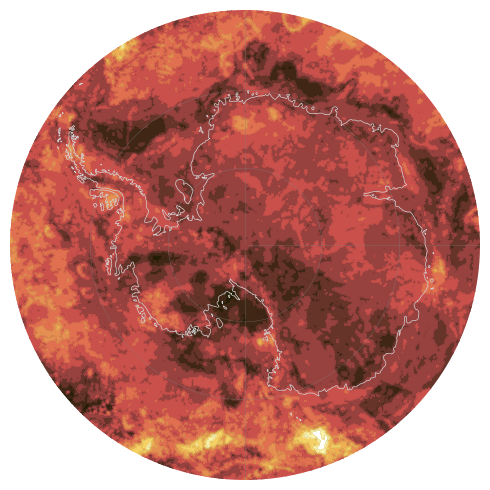

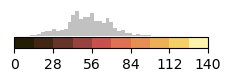

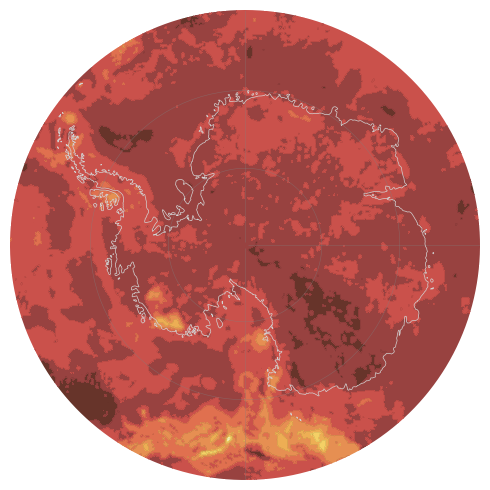

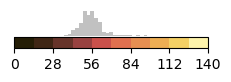

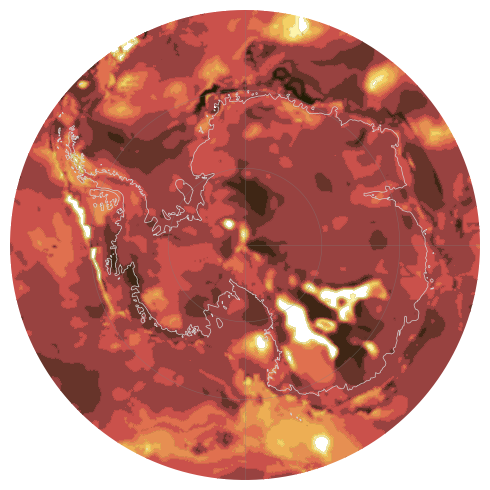

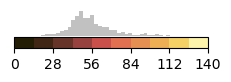

(<Figure size 500x500 with 1 Axes>, <GeoAxes: >)

In [17]:

ant_map(
    agrid_aq_gbm,
    'gbm_q50_corr',
    save_cbar='fig/aq2_gbm_q_cbar.png',
    save_fig='fig/aq2_gbm_q.png',
)


ant_map(
    agrid_aq_qrf,
    'qrf_q50_corr',
    save_cbar='fig/aq2_qrf_q_cbar.png',
    save_fig='fig/aq2_qrf_q.png',
)

ant_map(
    agrid_aq_sim,
    'sim_q_corr',
    save_cbar='fig/aq2_sim_q_cbar.png',
    save_fig='fig/aq2_sim_q.png',
)





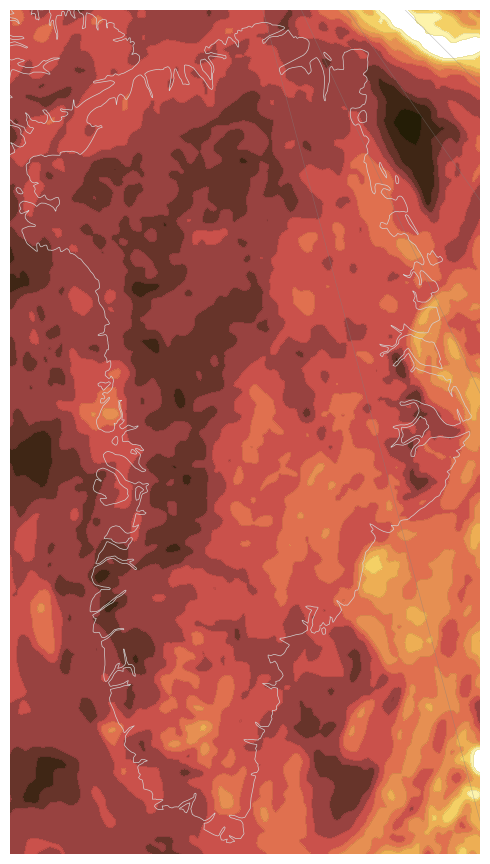

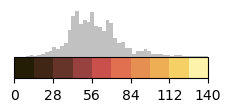

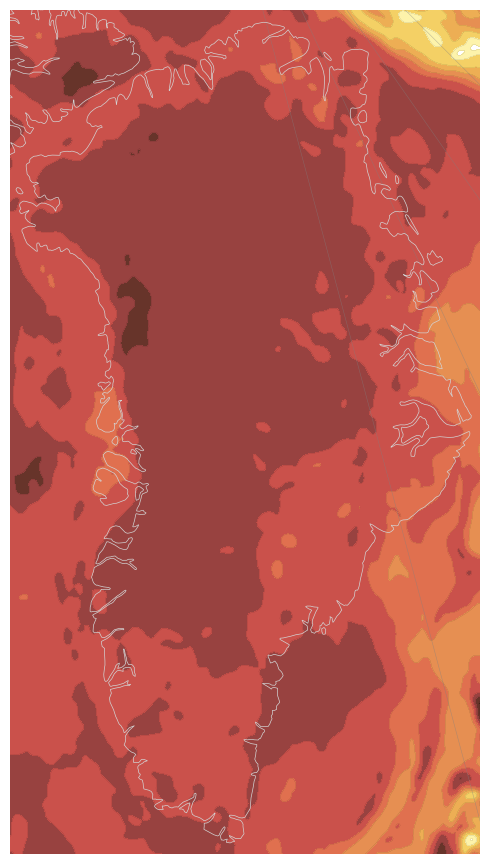

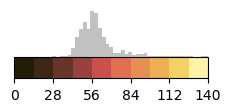

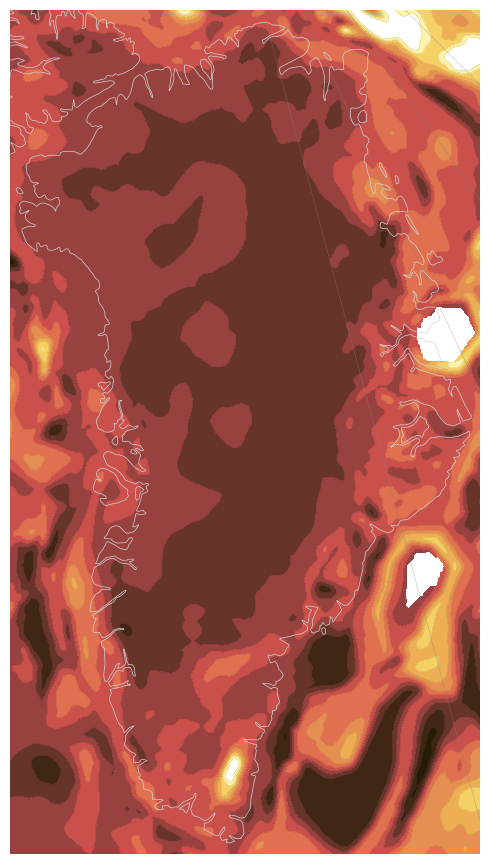

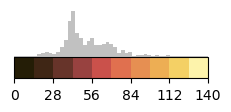

(<Figure size 500x898.058 with 1 Axes>, <GeoAxes: >)

In [18]:

grl_map(
    agrid_kq_gbm,
    'gbm_q50_corr',
    save_cbar='fig/kq2_gbm_q_cbar.png',
    save_fig='fig/kq2_gbm_q.png',
)


grl_map(
    agrid_kq_qrf,
    'qrf_q50_corr',
    save_cbar='fig/kq2_qrf_q_cbar.png',
    save_fig='fig/kq2_qrf_q.png',
)

grl_map(
    agrid_kq_sim,
    'sim_q_corr',
    save_cbar='fig/kq2_sim_q_cbar.png',
    save_fig='fig/kq2_sim_q.png',
)




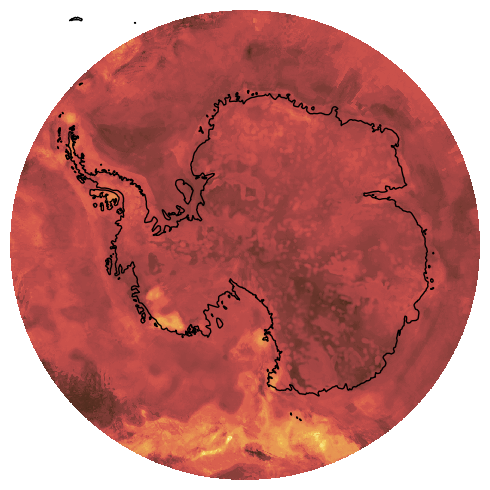

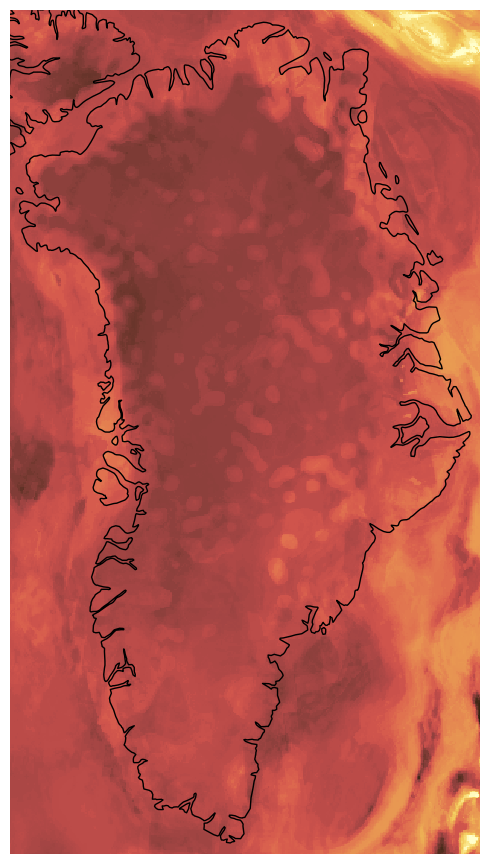

(<Figure size 500x898.058 with 1 Axes>, <GeoAxes: >)

In [19]:
agrid_aq_qrf.map('qrf_q50_corr', cmap = hf_cmap, vmin = q_min, vmax = q_max, transparent=True, save_fig='aq2_qrf_q.png')

agrid_kq_qrf.map('qrf_q50_corr', cmap = hf_cmap, vmin = q_min, vmax = q_max, transparent=True, save_fig='kq2_qrf_q.png')

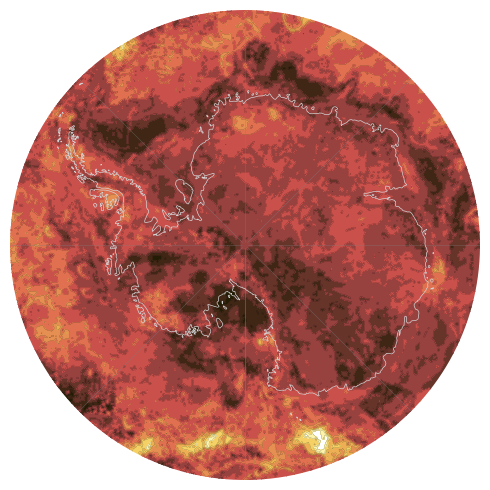

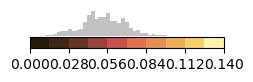

(<Figure size 500x500 with 1 Axes>, <GeoAxes: >)

In [20]:


agrid_aq_gbm.contour_map('gbm_q50_corr', 
                 cmap = hf_cmap, 
                 vmin = q_min, 
                 vmax = q_max, 
                 transparent=True, 
                 contour_linewidths=0.1,
                 smooth_kernel_size=2,
                 smooth=True,
                 circular = True,
                 gridlines={"step": 45},
                 ext_cbar=True,
                 save_cbar='fig/aq2_gbm_q_cbar.png',
                 save_fig='fig/aq2_gbm_q.png')






# agrid_kq_gbm.contour_map('gbm_q50_corr', 
#                  cmap = hf_cmap, 
#                  vmin = q_min, 
#                  vmax = q_max, 
#                  transparent=True, 
#                  smooth_kernel_size=2,
#                  contour_linewidths=0.3,
#                  smooth=True,
#                  save_fig='kq2_gbm_q.png')

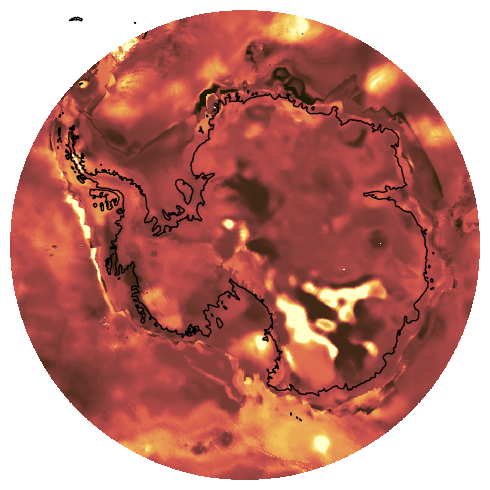

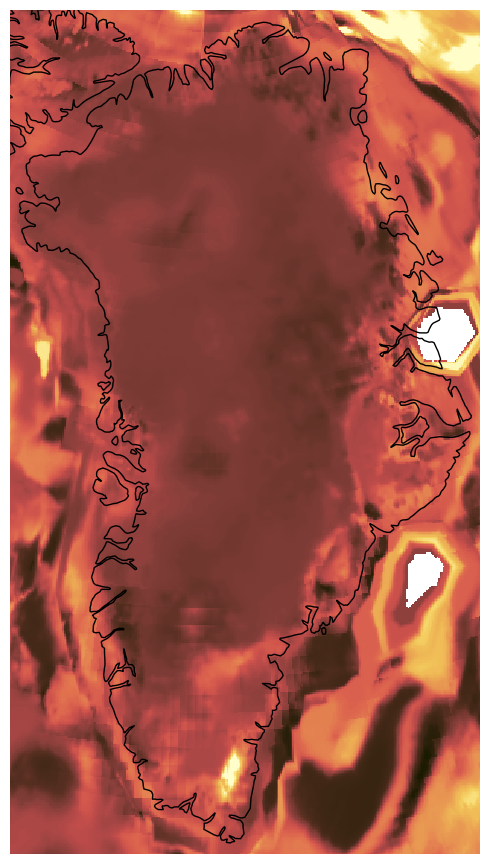

(<Figure size 500x898.058 with 1 Axes>, <GeoAxes: >)

In [21]:
agrid_aq_sim.map('sim_q_corr', cmap = hf_cmap, vmin = q_min, vmax = q_max, transparent=True, save_fig='aq2_sim_q.png')

agrid_kq_sim.map('sim_q_corr', cmap = hf_cmap, vmin = q_min, vmax = q_max, transparent=True, save_fig='kq2_sim_q.png')

In [22]:
aq_sim = xr.open_dataset('output/targets/Aq15_SIM_v0_2.nc')

In [23]:
from matplotlib import pyplot as plt

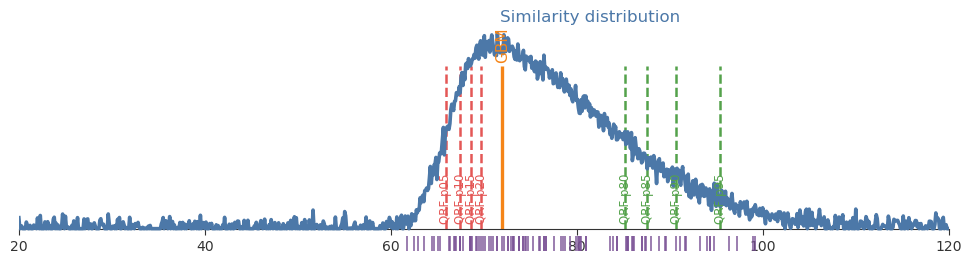

In [24]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import skewnorm

# -----------------------------
# Parameters
# -----------------------------
np.random.seed(7)

x = np.linspace(20, 120, 1000)

center = 66          # shifted a bit left so the peak sits near GBM
scale = 15
skew = 6             # positive => longer/stronger right tail

gbm = 72             # near, but not exactly on, the peak
n_samples = 100

# 4 lower + 4 upper percentiles
lower_ps = [5, 10, 15, 20]
upper_ps = [80, 85, 90, 95]

# -----------------------------
# Helpers
# -----------------------------
def jagged_noise(n, scale=0.035):
    return np.random.normal(0, scale, n)

# -----------------------------
# Distribution
# -----------------------------
y_base = skewnorm.pdf(x, a=skew, loc=center, scale=scale)
y_base /= y_base.max()

# Make the line a bit more rugged
y = y_base + jagged_noise(len(x), scale=0.035)
y = np.clip(y, 0, None)

# Sample markers from same distribution
samples = skewnorm.rvs(a=skew, loc=center, scale=scale, size=n_samples, random_state=7)
samples = samples[(samples >= 20) & (samples <= 120)]

# QRF percentile positions
qrf_percentiles = lower_ps + upper_ps
qrf_x = skewnorm.ppf(np.array(qrf_percentiles) / 100.0, a=skew, loc=center, scale=scale)
lower_x = qrf_x[:len(lower_ps)]
upper_x = qrf_x[len(lower_ps):]

# -----------------------------
# Figure
# -----------------------------
fig, ax = plt.subplots(figsize=(12, 3.2))
fig.patch.set_alpha(0)
ax.set_facecolor("none")

# Colors
c_dist = "#4C78A8"      # blue
c_gbm = "#F58518"       # orange
c_qrf_low = "#E45756"   # red
c_qrf_high = "#54A24B"  # green
c_rug = "#7A5195"       # purple
c_axis = "#333333"

# Main similarity distribution
ax.plot(x, y, color=c_dist, lw=2.6, zorder=3)

# Choose common line height for GBM and QRF percentile lines
line_top = 0.88

# GBM line
ax.vlines(gbm, ymin=0, ymax=line_top, colors=c_gbm, linewidth=2.4, zorder=2)

# QRF lines, same height as GBM
ax.vlines(lower_x, ymin=0, ymax=line_top, colors=c_qrf_low, linewidth=1.8, linestyles="--", zorder=1)
ax.vlines(upper_x, ymin=0, ymax=line_top, colors=c_qrf_high, linewidth=1.8, linestyles="--", zorder=1)

# Sample markers below x-axis
rug_y0 = -0.12
rug_y1 = -0.04
ax.vlines(samples, rug_y0, rug_y1, color=c_rug, lw=1.1, alpha=0.95, zorder=2)

# Labels
peak_x = x[np.argmax(y)]
ax.text(peak_x + 10, y.max() + 0.05, "Similarity distribution",
        color=c_dist, fontsize=12, ha="center", va="bottom")

ax.text(gbm, line_top + 0.02, "GBM",
        color=c_gbm, fontsize=11, ha="center", va="bottom", rotation=90)

for p, xp in zip(lower_ps, lower_x):
    ax.text(xp, 0.03, f"QRF p{p:02d}",
            color=c_qrf_low, fontsize=8.5,
            ha="center", va="bottom", rotation=90)

for p, xp in zip(upper_ps, upper_x):
    ax.text(xp, 0.03, f"QRF p{p:02d}",
            color=c_qrf_high, fontsize=8.5,
            ha="center", va="bottom", rotation=90)

# Axis styling
ax.set_xlim(20, 120)
ax.set_ylim(-0.18, 1.15)
ax.set_xticks(np.arange(20, 121, 20))
ax.set_yticks([])

ax.spines["left"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["top"].set_visible(False)
ax.spines["bottom"].set_position(("data", 0))
ax.spines["bottom"].set_color(c_axis)

ax.tick_params(axis="x", colors=c_axis, length=4)
ax.tick_params(axis="y", length=0)
ax.grid(False)

plt.savefig("similarity_skewed_qrf_percentiles.png",
            dpi=300, bbox_inches="tight", transparent=True)
plt.show()

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


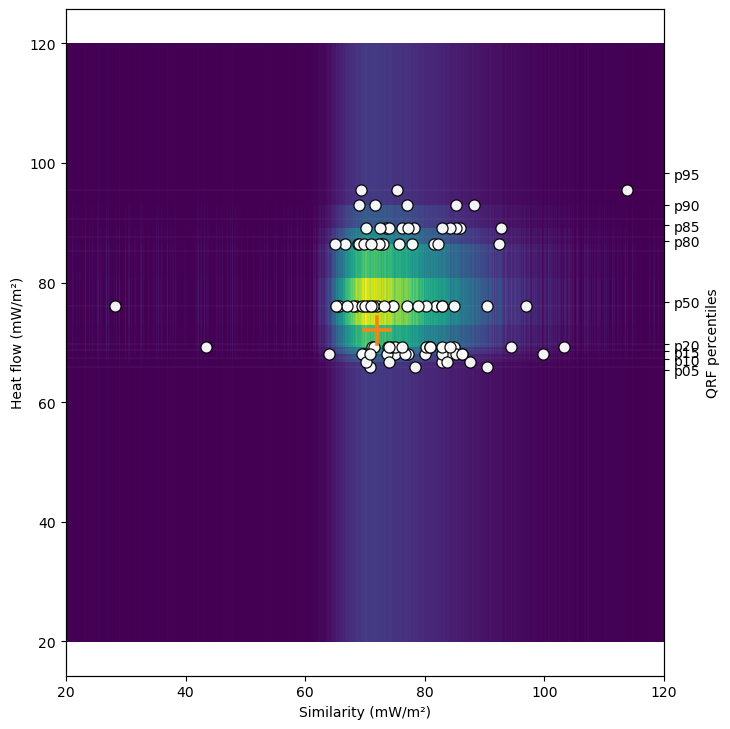

In [25]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import skewnorm

# ---------------------------------
# Parameters
# ---------------------------------
np.random.seed(7)

xmin, xmax = 20, 120
ymin, ymax = 20, 120
nx, ny = 700, 700

gbm = 72
n_samples = 100

# Similarity distribution
center = 66
scale = 15
skew = 6

# Quantiles used for labeled anchors
percentiles = np.array([5, 10, 15, 20, 80, 85, 90, 95], dtype=float)

# Weights highest near center, lower toward tails
qrf_weights = np.array([0.25, 0.45, 0.70, 1.00, 1.00, 0.70, 0.45, 0.25], dtype=float)

# ---------------------------------
# Similarity in x
# ---------------------------------
x = np.linspace(xmin, xmax, nx)

sim = skewnorm.pdf(x, a=skew, loc=center, scale=scale)
sim /= sim.max()
sim = sim + np.random.normal(0, 0.03, size=sim.size)
sim = np.clip(sim, 0, None)
sim /= sim.max()

# ---------------------------------
# True QRF quantile values on y-axis
# ---------------------------------
q05, q10, q15, q20, q80, q85, q90, q95 = skewnorm.ppf(
    percentiles / 100.0, a=skew, loc=center, scale=scale
)
q50 = skewnorm.ppf(0.50, a=skew, loc=center, scale=scale)

qvals = np.clip(np.array([q05, q10, q15, q20, q50, q80, q85, q90, q95]), ymin, ymax)
q05, q10, q15, q20, q50, q80, q85, q90, q95 = qvals

# ---------------------------------
# Build y bands using true values
# ---------------------------------
band_centers = np.array([
    q05,
    0.5 * (q05 + q10),
    0.5 * (q10 + q15),
    0.5 * (q15 + q20),
    q50,                  # anything between p20 and p80 snaps here
    0.5 * (q80 + q85),
    0.5 * (q85 + q90),
    0.5 * (q90 + q95),
    q95
])

band_edges = np.array([
    ymin,
    0.5 * (q05 + q10),
    0.5 * (q10 + q15),
    0.5 * (q15 + q20),
    0.5 * (q20 + q50),
    0.5 * (q50 + q80),
    0.5 * (q80 + q85),
    0.5 * (q85 + q90),
    0.5 * (q90 + q95),
    ymax
])

band_weights = np.array([0.18, 0.30, 0.50, 0.75, 1.00, 0.75, 0.50, 0.30, 0.18], dtype=float)

# Fine y grid
y = np.linspace(ymin, ymax, ny)
band_idx = np.digitize(y, band_edges[1:-1], right=False)
qrf_y = band_weights[band_idx]

# ---------------------------------
# 2D field = SIM(x) * QRF(y)
# ---------------------------------
Z = np.outer(qrf_y, sim)
Z /= Z.max()

# ---------------------------------
# Sample points
# x sampled continuously from similarity
# y snapped to center of the percentile band
# ---------------------------------
sim_prob = sim / sim.sum()
x_samples = np.random.choice(x, size=n_samples, p=sim_prob)

band_probs = band_weights / band_weights.sum()
sample_band_idx = np.random.choice(np.arange(len(band_centers)), size=n_samples, p=band_probs)
y_samples = band_centers[sample_band_idx]

# ---------------------------------
# Plot
# ---------------------------------
fig, ax = plt.subplots(figsize=(7.4, 7.4))
fig.patch.set_alpha(0)
ax.set_facecolor("none")

mesh = ax.pcolormesh(x, y, Z, shading="auto", cmap="viridis")

# Sample points
ax.scatter(
    x_samples, y_samples,
    s=64, facecolor="white", edgecolor="black",
    linewidth=0.9, alpha=0.95, zorder=4
)

# GBM cross at (72, 72)
cross_half = 2.2
ax.plot([gbm - cross_half, gbm + cross_half], [gbm, gbm],
        color="#F58518", lw=2.6, zorder=5)
ax.plot([gbm, gbm], [gbm - cross_half, gbm + cross_half],
        color="#F58518", lw=2.6, zorder=5)

# Left axis: numeric mW/m², same style as x-axis
ticks_20_120 = np.arange(20, 121, 20)
ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)
ax.set_xticks(ticks_20_120)
ax.set_yticks(ticks_20_120)

ax.set_xlabel("Similarity (mW/m²)")
ax.set_ylabel("Heat flow (mW/m²)")

# Square plot
ax.set_aspect('equal', adjustable='box')

# Subtle guides at true quantile levels
for yc in [q05, q10, q15, q20, q50, q80, q85, q90, q95]:
    ax.axhline(yc, color="white", lw=0.35, alpha=0.12, zorder=2)

# Right axis: percentile labels at true quantile values
ax_r = ax.twinx()
ax_r.set_ylim(ymin, ymax)
ax_r.set_yticks([q05, q10, q15, q20, q50, q80, q85, q90, q95])
ax_r.set_yticklabels(["p05", "p10", "p15", "p20", "p50", "p80", "p85", "p90", "p95"])
ax_r.set_ylabel("QRF percentiles")

# Colorbar
# cbar = plt.colorbar(mesh, ax=ax, pad=0.02)
# cbar.set_label("SIM × QRF")

plt.tight_layout()
plt.savefig("similarity_qrf_square_dualyaxis.png",
            dpi=300, bbox_inches="tight", transparent=True)
plt.show()

In [26]:
plt.hist(pt_dist[1, 200,:])

NameError: name 'pt_dist' is not defined